# Strategy 8: Information Decay / Half-Life Trading

**Thesis**: When two speakers give opposing views within 48 hours, the second speech's effect
is amplified because it's a *reversal* of the prior tone. The market re-prices when the committee
shows internal conflict.

**Signal**: Compare the current speaker's most recent hawk\_dove\_score to the committee-wide
average score across ALL speeches in the prior 48 hours (2 business days).
- `tone_reversal = speaker_prior_score - recent_committee_avg`
- Trade when |tone\_reversal| >= threshold

**Variants tested**:
1. Reversal Only (|reversal| >= 15)
2. Reversal + Level confirmation (reversal + trailing\_5\_avg agree on direction)
3. Baseline (trailing\_5\_avg level at +/-10)

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET  = datetime.timedelta(minutes=180)
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END   = "2026-06-30"

REVERSAL_THRESH = 15
LEVEL_THRESH    = 10
LOOKBACK_DAYS   = 2

EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)
BLACKOUT_BD = 1

print("Config loaded.")
print(f"Reversal threshold: {REVERSAL_THRESH}")
print(f"48hr lookback: {LOOKBACK_DAYS} business days")

Config loaded.
Reversal threshold: 15
48hr lookback: 2 business days


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme
fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"]).dt.date
jpm = jpm.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN_SPEAKERS = sorted(jpm["speaker"].unique())
print(f"JPM speakers: {len(KNOWN_SPEAKERS)}")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1483
JPM speakers: 23


## 2. Engine & Helpers

In [3]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

FOMC_DATES = [
    datetime.date(2020,1,29),datetime.date(2020,3,15),datetime.date(2020,4,29),
    datetime.date(2020,6,10),datetime.date(2020,7,29),datetime.date(2020,9,16),
    datetime.date(2020,11,5),datetime.date(2020,12,16),
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

def is_in_blackout(event_date):
    for f in FOMC_DATES:
        s = ql.Date(f.day, f.month, f.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False

def cap_exit(exit_ts, entry_ts):
    eq = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(eq):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts

# Per-speaker caches
_caches = {}
for col in ["trailing_5_avg", "hawk_dove_score"]:
    cache = {}
    for speaker, grp in jpm.groupby("speaker"):
        g = grp.sort_values("date")
        cache[speaker] = (g["date"].values, g[col].values)
    _caches[col] = cache

def _lookup(col, speaker, as_of):
    if speaker not in _caches[col]: return np.nan
    dates, vals = _caches[col][speaker]
    mask = dates < np.datetime64(as_of)
    return float(vals[mask][-1]) if mask.any() else np.nan

# Committee-wide 48hr lookback: all hawk_dove_score values within LOOKBACK_DAYS bdays before as_of
_all_scores = jpm[["date", "hawk_dove_score"]].copy()
_all_scores = _all_scores.sort_values("date")

def _recent_committee_avg(as_of_date):
    # Average hawk_dove_score across all speeches in the prior LOOKBACK_DAYS business days
    as_of_ql = ql.Date(as_of_date.day, as_of_date.month, as_of_date.year)
    start_ql = ql_cal.advance(as_of_ql, ql.Period(-LOOKBACK_DAYS, ql.Days), ql.Preceding)
    start_date = datetime.date(start_ql.year(), start_ql.month(), start_ql.dayOfMonth())
    mask = (_all_scores["date"] >= start_date) & (_all_scores["date"] < as_of_date)
    subset = _all_scores[mask]
    if len(subset) == 0:
        return np.nan
    return subset["hawk_dove_score"].mean()

def _sharpe(cl):
    n = len(cl)
    if n < 2: return 0
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(tpy)) if std > 0 else 0

print("Engine ready.")

Engine ready.


## 3. Compute Tone Reversal for All Speeches

In [4]:
# Pre-compute tone_reversal for every speech in the JPM CSV
reversal_data = []
for _, row in jpm.iterrows():
    speaker = row["speaker"]
    speech_date = row["date"]
    speaker_score = row["hawk_dove_score"]
    committee_avg = _recent_committee_avg(speech_date)
    if pd.isna(committee_avg):
        continue
    reversal = speaker_score - committee_avg
    reversal_data.append({
        "date": speech_date,
        "speaker": speaker,
        "hawk_dove_score": speaker_score,
        "trailing_5_avg": row["trailing_5_avg"],
        "committee_48hr_avg": committee_avg,
        "tone_reversal": reversal,
    })

reversal_df = pd.DataFrame(reversal_data)
print(f"Speeches with reversal data: {len(reversal_df)}")
print(f"\nTone reversal distribution:")
print(reversal_df["tone_reversal"].describe().to_string())
print(f"\nSpeeches with |reversal| >= {REVERSAL_THRESH}: {(reversal_df['tone_reversal'].abs() >= REVERSAL_THRESH).sum()}")
print(f"  Hawk reversals (>{REVERSAL_THRESH}): {(reversal_df['tone_reversal'] >= REVERSAL_THRESH).sum()}")
print(f"  Dove reversals (<-{REVERSAL_THRESH}): {(reversal_df['tone_reversal'] <= -REVERSAL_THRESH).sum()}")

Speeches with reversal data: 487

Tone reversal distribution:
count    487.000000
mean      -1.829447
std       22.412830
min      -83.000000
25%      -13.750000
50%        0.000000
75%       12.250000
max       71.000000

Speeches with |reversal| >= 15: 219
  Hawk reversals (>15): 101
  Dove reversals (<-15): 118


## 4. Build Trade Events — All Variants

In [5]:
def common_filters(row):
    speaker = extract_speaker(row["Title"])
    if speaker not in KNOWN_SPEAKERS: return None
    ts = row["TimestampNYC"]
    if pd.isna(ts): return None
    if ts.tzinfo is None: ts = NYC_tz.localize(ts)
    if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH: return None
    if is_in_blackout(ts.date()): return None
    if "press conference" in row["Title"].lower(): return None
    entry = ts - ENTRY_OFFSET
    eq = ql.Date(entry.day, entry.month, entry.year)
    if not ql_cal.isBusinessDay(eq): return None
    exit_ = cap_exit(ts + EXIT_OFFSET, entry)
    return speaker, ts, entry, exit_

def _dedup(events):
    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last: continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt

# Build a lookup for tone_reversal by (speaker, date)
_reversal_lookup = {}
for _, r in reversal_df.iterrows():
    _reversal_lookup[(r["speaker"], r["date"])] = r["tone_reversal"]

def get_prior_reversal(speaker, as_of_date):
    # Get the most recent tone_reversal for this speaker BEFORE as_of_date
    if speaker not in _caches["hawk_dove_score"]:
        return np.nan
    dates = _caches["hawk_dove_score"][speaker][0]
    mask = dates < np.datetime64(as_of_date)
    if not mask.any():
        return np.nan
    prior_date = pd.Timestamp(dates[mask][-1]).date()
    return _reversal_lookup.get((speaker, prior_date), np.nan)

def build_reversal_events():
    events = []
    for _, row in fed_speak_df.iterrows():
        result = common_filters(row)
        if result is None: continue
        speaker, ts, entry, exit_ = result
        rev = get_prior_reversal(speaker, ts.date())
        if pd.isna(rev) or abs(rev) < REVERSAL_THRESH: continue
        d = 1 if rev > 0 else -1
        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "signal_type": "reversal",
            "tone_reversal": rev,
            "t5": _lookup("trailing_5_avg", speaker, ts.date()),
            "bpv": -d * BASE_BPV, "tag": f"r_{len(events)}",
        })
    return _dedup(events)

def build_reversal_confirmed_events():
    events = []
    for _, row in fed_speak_df.iterrows():
        result = common_filters(row)
        if result is None: continue
        speaker, ts, entry, exit_ = result
        rev = get_prior_reversal(speaker, ts.date())
        t5 = _lookup("trailing_5_avg", speaker, ts.date())
        if pd.isna(rev) or pd.isna(t5): continue
        if abs(rev) < REVERSAL_THRESH: continue
        d_rev = 1 if rev > 0 else -1
        d_level = 1 if t5 >= LEVEL_THRESH else (-1 if t5 <= -LEVEL_THRESH else 0)
        if d_level == 0 or d_rev != d_level: continue
        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d_rev, "signal_type": "reversal_confirmed",
            "tone_reversal": rev, "t5": t5,
            "bpv": -d_rev * BASE_BPV, "tag": f"rc_{len(events)}",
        })
    return _dedup(events)

def build_baseline_events():
    events = []
    for _, row in fed_speak_df.iterrows():
        result = common_filters(row)
        if result is None: continue
        speaker, ts, entry, exit_ = result
        t5 = _lookup("trailing_5_avg", speaker, ts.date())
        if pd.isna(t5): continue
        if t5 >= LEVEL_THRESH: d = 1
        elif t5 <= -LEVEL_THRESH: d = -1
        else: continue
        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "signal_type": "level",
            "tone_reversal": get_prior_reversal(speaker, ts.date()),
            "t5": t5,
            "bpv": -d * BASE_BPV, "tag": f"bl_{len(events)}",
        })
    return _dedup(events)

strategies = {}
for name, builder in [("Reversal Only", build_reversal_events),
                       ("Reversal + Level", build_reversal_confirmed_events),
                       ("Baseline (t5 level)", build_baseline_events)]:
    evts = builder()
    strategies[name] = evts
    n_h = sum(1 for e in evts if e["direction"] == 1)
    n_d = sum(1 for e in evts if e["direction"] == -1)
    print(f"{name:25s}: {len(evts):4d} trades (hawk={n_h}, dove={n_d})")

Reversal Only            :  271 trades (hawk=145, dove=126)


Reversal + Level         :  125 trades (hawk=108, dove=17)


Baseline (t5 level)      :  461 trades (hawk=386, dove=75)


## 5. Run Backtests

In [6]:
def run_bt(events, label):
    if len(events) < 3:
        print(f"  {label}: too few events ({len(events)}), skipping")
        return None
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={k: ev[k] for k in ["speaker","direction","signal_type","tone_reversal","t5"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=label, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {label}")
    bt.run()
    return bt

def extract(bt):
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    for col in ["speaker","direction","signal_type","tone_reversal","t5"]:
        cl[col] = cl["source_query"].apply(lambda q: q.meta.get(col))
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["closed_at"] = pd.to_datetime(cl["closed_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl

all_closed = {}
for name, evts in strategies.items():
    print(f"\n--- {name} ---")
    bt = run_bt(evts, name)
    if bt is None:
        continue
    cl = extract(bt)
    all_closed[name] = cl
    print(f"  Closed: {len(cl)}, Cum: {cl['pnl_bps'].sum():+.1f} bps")

print("\nAll backtests complete.")


--- Reversal Only ---


  Reversal Only:   0%|          | 0/542 [00:00<?, ?step/s]

  Reversal Only:   0%|          | 1/542 [00:00<05:36,  1.61step/s]

  Reversal Only:   1%|          | 4/542 [00:00<01:19,  6.73step/s]

  Reversal Only:   1%|▏         | 7/542 [00:00<00:51, 10.48step/s]

...

  Baseline (t5 level):  99%|█████████▉| 910/916 [00:41<00:00, 26.83step/s]

  Baseline (t5 level): 100%|█████████▉| 913/916 [00:41<00:00, 26.01step/s]

  Baseline (t5 level): 100%|██████████| 916/916 [00:41<00:00, 26.91step/s]

  Baseline (t5 level): 100%|██████████| 916/916 [00:41<00:00, 22.15step/s]

  Closed: 455, Cum: +181.3 bps

All backtests complete.


## 6. Equity Curves & Drawdown

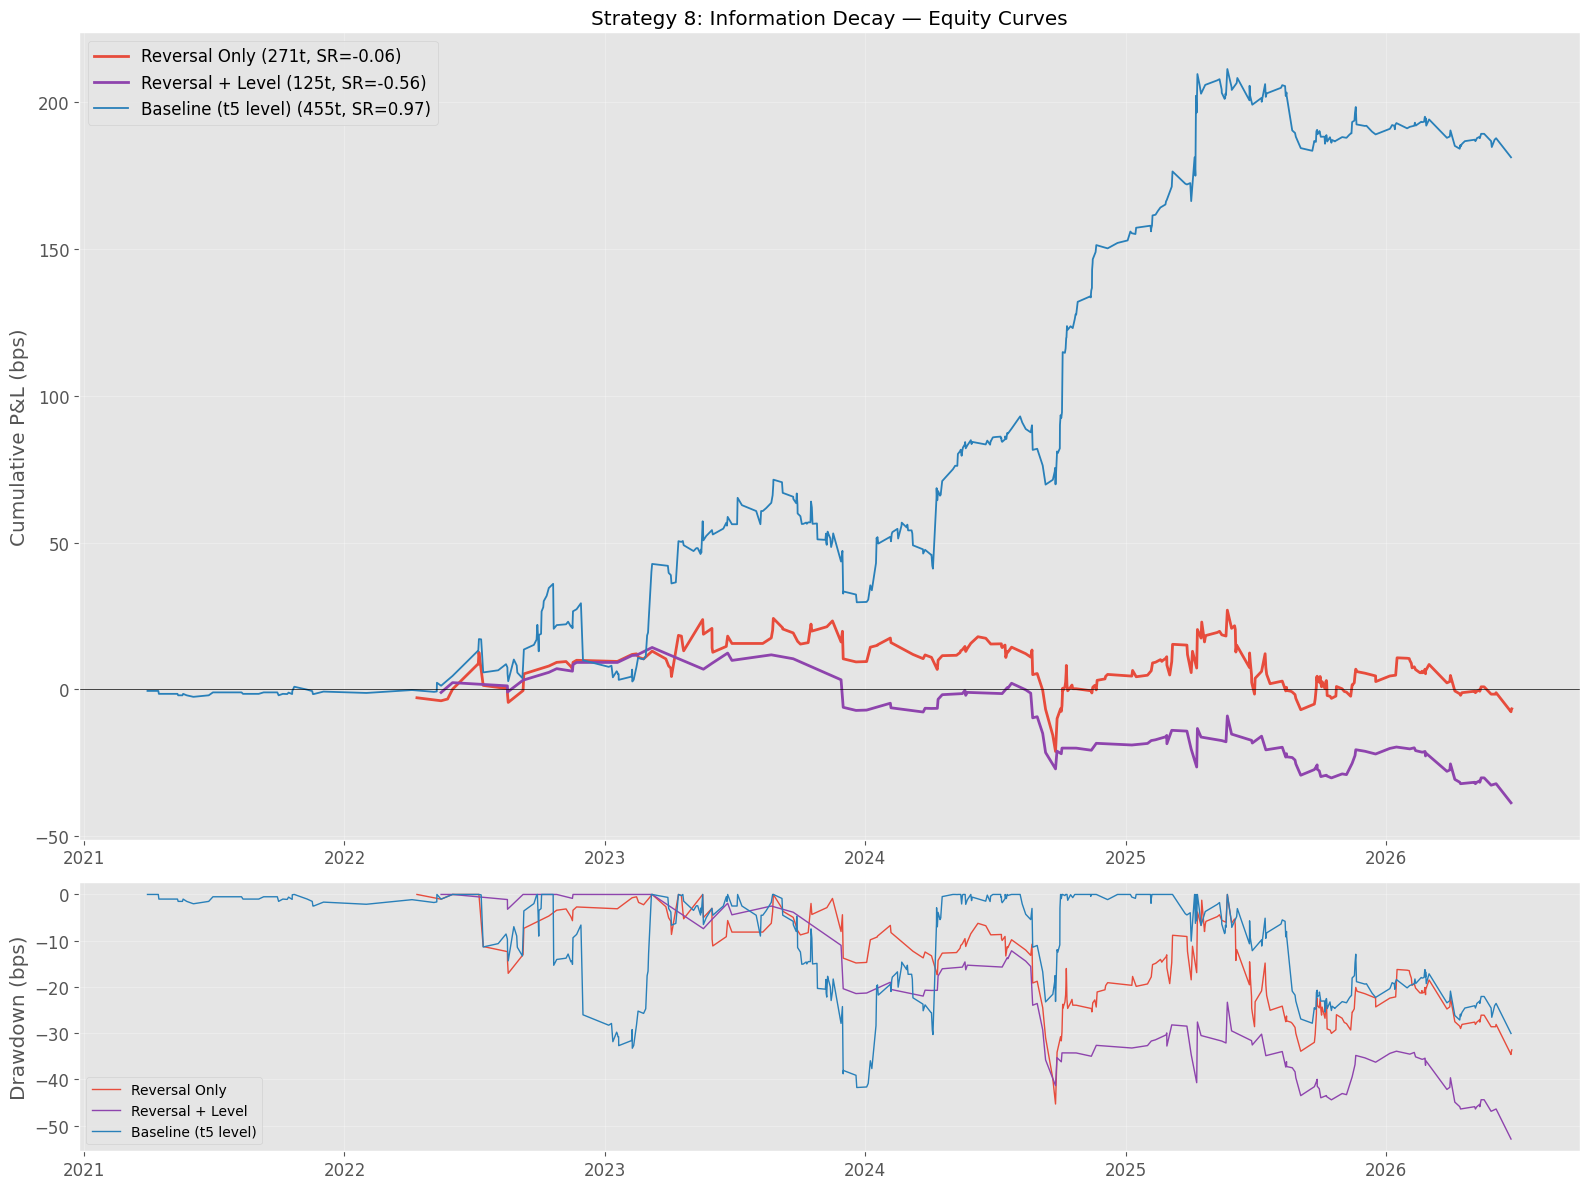

In [7]:
COLORS = {"Reversal Only": "#e74c3c", "Reversal + Level": "#8e44ad", "Baseline (t5 level)": "#2980b9"}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for name in all_closed:
    cl = all_closed[name]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=2 if "Reversal" in name else 1.3, color=COLORS.get(name, "grey"),
            label=f"{name} ({len(cl)}t, SR={_sharpe(cl):.2f})")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Strategy 8: Information Decay — Equity Curves")
ax.legend(loc="upper left", fontsize=12)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for name in all_closed:
    cl = all_closed[name]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.plot(cl["opened_at"].values, dd.values, lw=1, color=COLORS.get(name, "grey"), label=name)
ax2.set_ylabel("Drawdown (bps)")
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Summary Table

In [8]:
def calc_stats(cl, name):
    hawk = cl["direction"] == 1
    return {
        "Strategy": name, "Trades": len(cl),
        "Hawk / Dove": f"{hawk.sum()} / {(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": cl["pnl_bps"].mean(),
        "Med bps": cl["pnl_bps"].median(),
        "Hit Rate": cl["profitable"].mean(),
        "Sharpe": _sharpe(cl),
        "Max DD": (cl["cum_bps"] - cl["cum_bps"].cummax()).min(),
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum(),
    }

rows = [calc_stats(all_closed[n], n) for n in all_closed]
summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}", "Max DD": "{:.1f}",
    "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Strategy,Trades,Hawk / Dove,Cum bps,Avg bps,Med bps,Hit Rate,Sharpe,Max DD,Hawk bps,Dove bps
0,Reversal Only,271,145 / 126,-6.6,-0.024,+0.003,51.3%,-0.06,-45.3,-39.3,+32.6
1,Reversal + Level,125,108 / 17,-38.6,-0.309,-0.063,47.2%,-0.56,-52.9,-21.5,-17.1
2,Baseline (t5 level),455,380 / 75,+181.3,+0.398,+0.147,57.4%,0.97,-41.8,+197.3,-16.0


## 8. Calendar-Year Breakdown

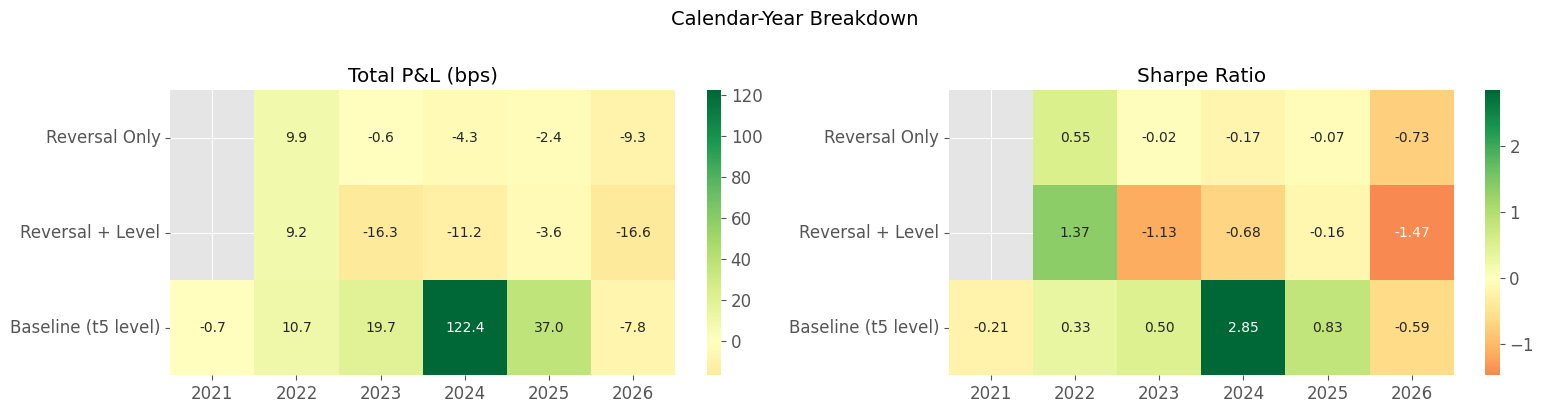


Reversal Only:
  2022:  20 trades,    +9.9 bps, hit=60%
  2023:  41 trades,    -0.6 bps, hit=44%
  2024:  70 trades,    -4.3 bps, hit=59%
  2025:  98 trades,    -2.4 bps, hit=45%
  2026:  42 trades,    -9.3 bps, hit=57%

Reversal + Level:
  2022:  10 trades,    +9.2 bps, hit=60%
  2023:  14 trades,   -16.3 bps, hit=43%
  2024:  30 trades,   -11.2 bps, hit=50%
  2025:  45 trades,    -3.6 bps, hit=42%
  2026:  26 trades,   -16.6 bps, hit=50%

Baseline (t5 level):
  2021:  39 trades,    -0.7 bps, hit=51%
  2022:  49 trades,   +10.7 bps, hit=63%
  2023:  97 trades,   +19.7 bps, hit=51%
  2024: 121 trades,  +122.4 bps, hit=64%
  2025: 104 trades,   +37.0 bps, hit=54%
  2026:  45 trades,    -7.8 bps, hit=60%


In [9]:
all_years = sorted(set(y for cl in all_closed.values() for y in cl["year"].unique()))
yr_bps = pd.DataFrame(index=list(all_closed.keys()), columns=all_years, dtype=float)
yr_sr = yr_bps.copy()

for name in all_closed:
    cl = all_closed[name]
    for yr, grp in cl.groupby("year"):
        n = len(grp); avg = grp["pnl_bps"].mean(); std = grp["pnl_bps"].std()
        yr_bps.loc[name, yr] = grp["pnl_bps"].sum()
        yr_sr.loc[name, yr] = (avg / std * np.sqrt(n)) if std > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(yr_bps.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Total P&L (bps)")
sns.heatmap(yr_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Sharpe Ratio")
for ax in axes: ax.set_ylabel("")
plt.suptitle("Calendar-Year Breakdown", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Also print as table
for name in all_closed:
    print(f"\n{name}:")
    cl = all_closed[name]
    for yr, grp in cl.groupby("year"):
        n = len(grp); s = grp["pnl_bps"].sum(); h = grp["profitable"].mean()
        print(f"  {yr}: {n:3d} trades, {s:+7.1f} bps, hit={h:.0%}")

## 9. Tone Reversal Distribution

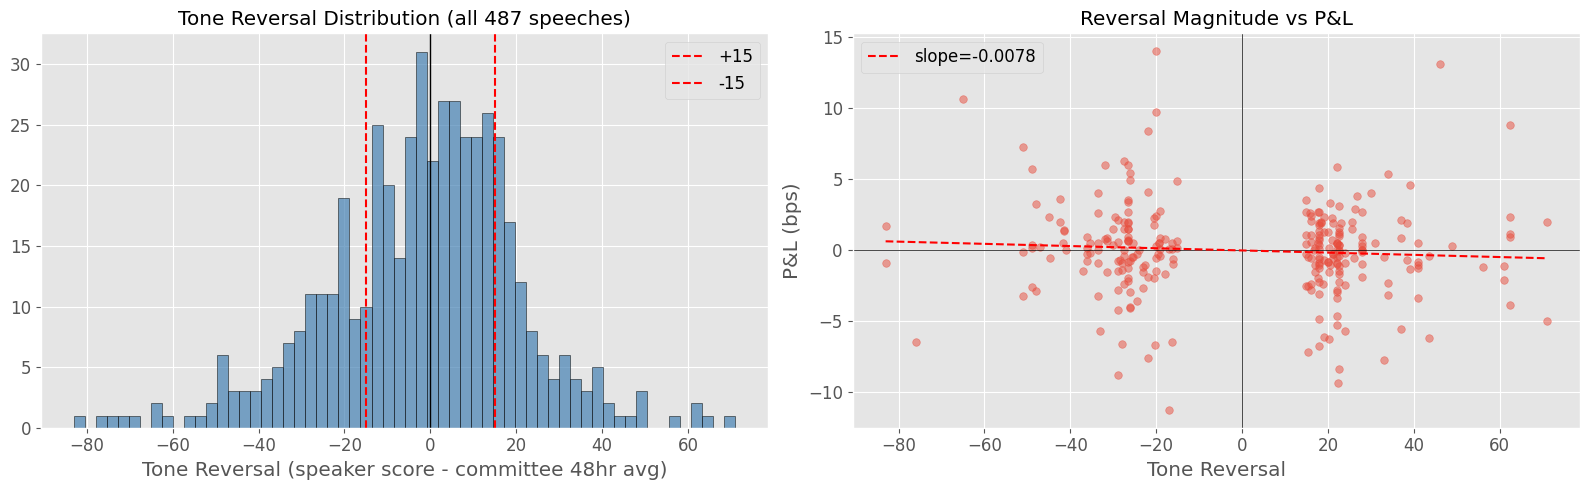

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of all tone reversals
ax = axes[0]
ax.hist(reversal_df["tone_reversal"], bins=60, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(REVERSAL_THRESH, color="red", ls="--", lw=1.5, label=f"+{REVERSAL_THRESH}")
ax.axvline(-REVERSAL_THRESH, color="red", ls="--", lw=1.5, label=f"-{REVERSAL_THRESH}")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Tone Reversal (speaker score - committee 48hr avg)")
ax.set_title(f"Tone Reversal Distribution (all {len(reversal_df)} speeches)")
ax.legend()

# Scatter: reversal magnitude vs P&L for reversal-only trades
if "Reversal Only" in all_closed:
    ax2 = axes[1]
    cl = all_closed["Reversal Only"]
    rev_vals = cl["tone_reversal"].astype(float)
    ax2.scatter(rev_vals, cl["pnl_bps"], alpha=0.5, s=30, color="#e74c3c")
    ax2.axhline(0, color="k", lw=0.5)
    ax2.axvline(0, color="k", lw=0.5)
    z = np.polyfit(rev_vals.dropna(), cl.loc[rev_vals.dropna().index, "pnl_bps"], 1)
    x_line = np.linspace(rev_vals.min(), rev_vals.max(), 100)
    ax2.plot(x_line, np.polyval(z, x_line), "r--", lw=1.5, label=f"slope={z[0]:.4f}")
    ax2.set_xlabel("Tone Reversal")
    ax2.set_ylabel("P&L (bps)")
    ax2.set_title("Reversal Magnitude vs P&L")
    ax2.legend()

plt.tight_layout(); plt.show()

## 10. Hawk vs Dove — Reversal Strategy

,trades,total_bps,avg_bps,hit_rate
direction_label,,,,
dove,126,+32.6,+0.259,55.6%
hawk,145,-39.3,-0.271,47.6%


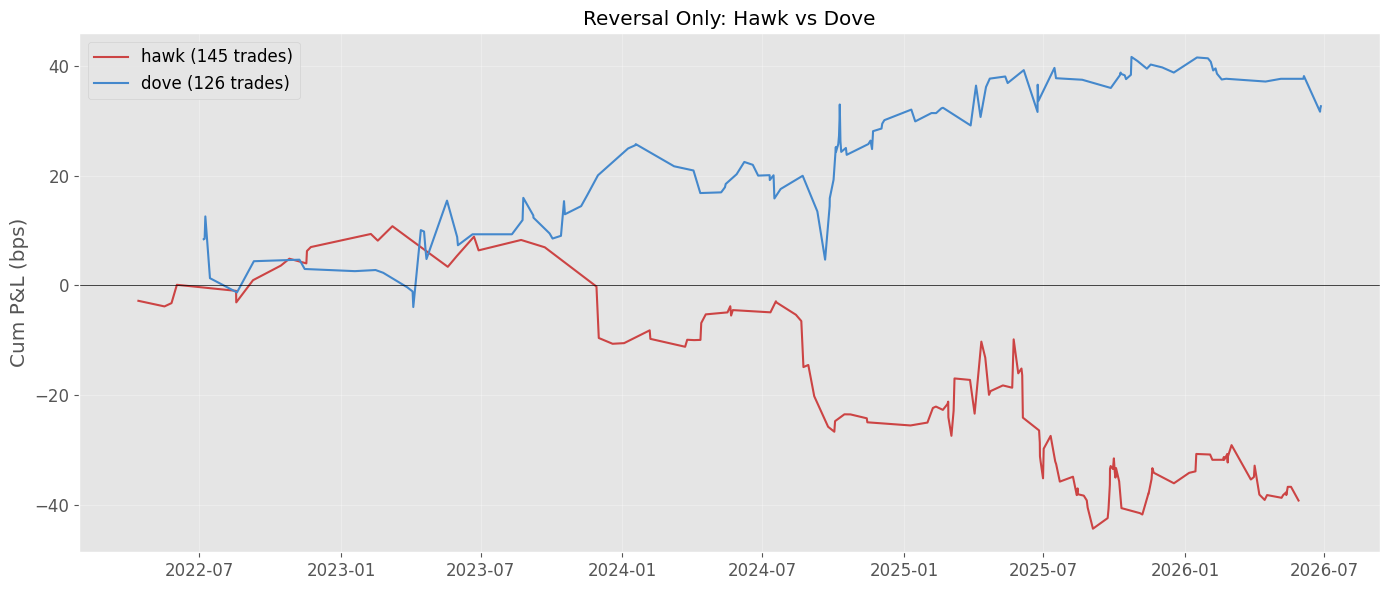

In [11]:
if "Reversal Only" in all_closed:
    cl = all_closed["Reversal Only"]
    dir_stats = cl.groupby("direction_label").agg(
        trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
    ).sort_values("total_bps", ascending=False)
    display(dir_stats.style.format({
        "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}"}))

    fig, ax = plt.subplots(figsize=(14, 6))
    for label, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
        mask = cl["direction_label"] == label
        sub = cl[mask].sort_values("opened_at")
        if len(sub) == 0: continue
        ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
                lw=1.5, color=color, label=f"{label} ({mask.sum()} trades)")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("Cum P&L (bps)"); ax.set_title("Reversal Only: Hawk vs Dove")
    ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 11. Speaker Attribution — Reversal Only

,trades,total_bps,avg_bps,hit_rate,avg_reversal
speaker,,,,,
Musalem,12,+18.7,+1.556,58.3%,38.3
Williams,26,+14.6,+0.563,53.8%,-16.7
Collins,5,+11.3,+2.269,60.0%,-11.9
Bostic,32,+10.1,+0.315,62.5%,14.4
Barr,14,+8.6,+0.617,64.3%,-27.4
Schmid,5,+7.0,+1.406,80.0%,29.4
Logan,5,+6.2,+1.237,60.0%,-29.9
Harker,11,+5.3,+0.482,54.5%,-20.2
George,2,+3.1,+1.547,50.0%,-49.0


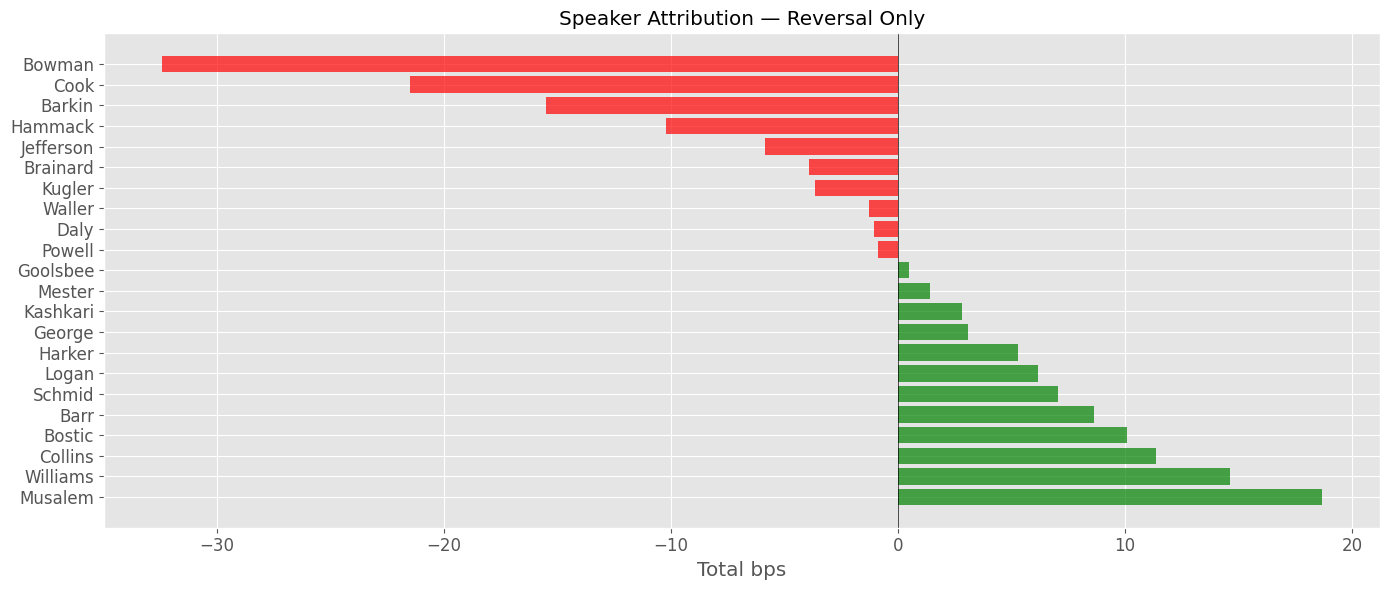

In [12]:
if "Reversal Only" in all_closed:
    cl = all_closed["Reversal Only"]
    sp = cl.groupby("speaker").agg(
        trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
        avg_reversal=("tone_reversal", "mean"),
    ).sort_values("total_bps", ascending=False)
    display(sp.style.format({
        "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}",
        "avg_reversal": "{:.1f}"}))

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ["green" if x > 0 else "red" for x in sp["total_bps"]]
    ax.barh(sp.index, sp["total_bps"], color=colors, alpha=0.7)
    ax.axvline(0, color="k", lw=0.5); ax.set_xlabel("Total bps")
    ax.set_title("Speaker Attribution — Reversal Only")
    plt.tight_layout(); plt.show()

## 12. Trade Log — Reversal Only

In [13]:
if "Reversal Only" in all_closed:
    cl = all_closed["Reversal Only"]
    log = cl[["opened_at","closed_at","speaker","direction_label",
              "tone_reversal","t5","pnl_bps","profitable","cum_bps"]].copy()
    log = log.sort_values("opened_at").reset_index(drop=True)
    display(log.style.format({
        "tone_reversal": "{:.1f}", "t5": "{:.0f}",
        "pnl_bps": "{:+.2f}", "cum_bps": "{:+.1f}",
    }).bar(subset=["pnl_bps"], color=["#d65f5f", "#5fba7d"], align="zero"))

,opened_at,closed_at,speaker,direction_label,tone_reversal,t5,pnl_bps,profitable,cum_bps
0,2022-04-12 11:25:00-04:00,2022-04-12 15:10:00-04:00,Brainard,hawk,16.0,-5,-2.83,False,-2.8
1,2022-05-16 08:10:00-04:00,2022-05-16 11:55:00-04:00,Williams,hawk,20.5,27,-1.02,False,-3.9
2,2022-05-25 11:30:00-04:00,2022-05-25 15:15:00-04:00,Brainard,hawk,16.0,-5,+0.60,True,-3.3
3,2022-06-01 10:45:00-04:00,2022-06-01 14:30:00-04:00,Williams,hawk,20.5,27,+3.34,True,+0.1
4,2022-07-06 08:15:00-04:00,2022-07-06 12:00:00-04:00,Williams,dove,-22.0,35,+8.39,True,+8.5
5,2022-07-07 12:15:00-04:00,2022-07-07 16:00:00-04:00,Waller,dove,-17.0,33,+0.09,True,+8.6
6,2022-07-08 10:15:00-04:00,2022-07-08 14:00:00-04:00,Williams,dove,-22.0,35,+4.08,True,+12.6
7,2022-07-14 10:15:00-04:00,2022-07-14 14:00:00-04:00,Waller,dove,-17.0,33,-11.26,False,+1.4
8,2022-08-17 08:45:00-04:00,2022-08-17 12:30:00-04:00,Bowman,hawk,61.0,28,-1.10,False,+0.3
9,2022-08-17 13:35:00-04:00,2022-08-17 16:59:00-04:00,Bowman,hawk,61.0,28,-2.10,False,-1.8
